# Mutual Fund Analytics — Exploratory Data Analysis (EDA)

In [133]:
import pandas as pd
import plotly.graph_objects as go

# Load data
df = pd.read_csv("data/raw/04_monthly_sip_inflows.csv")

# Convert month column
df["month"] = pd.to_datetime(df["month"])

# Convert to string for Plotly export compatibility
df["month_str"] = df["month"].astype(str)

# Create figure
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=df["month_str"],
        y=df["sip_inflow_crore"],
        mode="lines+markers",
        name="SIP Inflow (₹ Crore)",
        line=dict(color="#FF6B35", width=3)
    )
)

# Find highest SIP inflow
max_row = df.loc[df["sip_inflow_crore"].idxmax()]

# Add annotation
fig.add_annotation(
    x=str(max_row["month_str"]),
    y=max_row["sip_inflow_crore"],
    text=f"All-Time High ₹{int(max_row['sip_inflow_crore']):,} Cr",
    showarrow=True,
    arrowhead=2,
    bgcolor="white",
    bordercolor="black"
)

# Layout
fig.update_layout(
    title="Monthly SIP Inflows (Jan 2022 – Dec 2025)",
    xaxis_title="Month",
    yaxis_title="SIP Inflow (₹ Crore)",
    template="plotly_white",
    height=600,
    width=1000
)

# Show chart
fig.show()

# Save chart
fig.write_image("reports/sip_inflow_trend.png")

print("Chart saved successfully.")

Chart saved successfully.


### Insight:
Monthly SIP inflows showed strong growth from 2022 to 2025, reaching an all-time high in December 2025, indicating increasing retail participation in mutual fund investments.

In [134]:
import pandas as pd

aum = pd.read_csv("data/raw/03_aum_by_fund_house.csv")

print(aum.columns)

aum.head()

Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')


,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


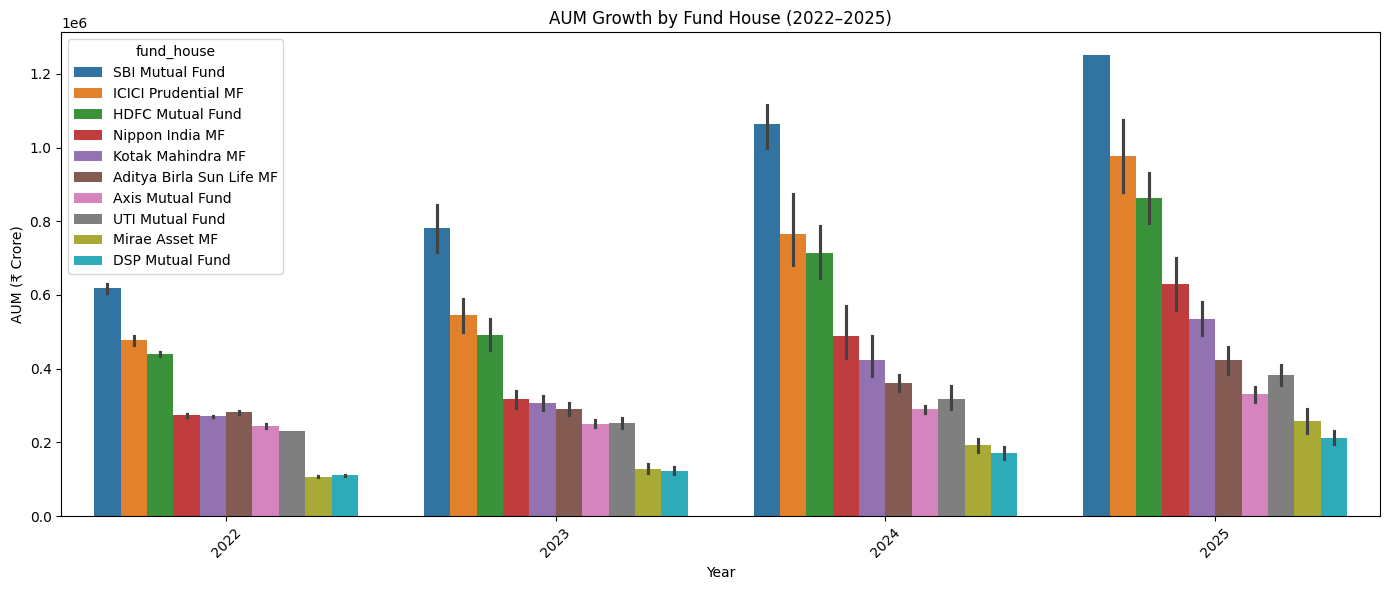

AUM chart saved successfully.


In [135]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
aum = pd.read_csv("data/raw/03_aum_by_fund_house.csv")

# Convert date column
aum["date"] = pd.to_datetime(aum["date"])

# Extract year
aum["year"] = aum["date"].dt.year

# Create chart
plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

# Titles
plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (₹ Crore)")

# Rotate labels
plt.xticks(rotation=45)

# Adjust layout
plt.tight_layout()

# Save chart
plt.savefig("reports/aum_growth_chart.png")

# Show chart
plt.show()

print("AUM chart saved successfully.")

### Insight:
SBI Mutual Fund consistently maintained the highest AUM between 2022 and 2025, showing strong market leadership among all fund houses.


Category Inflow Heatmap

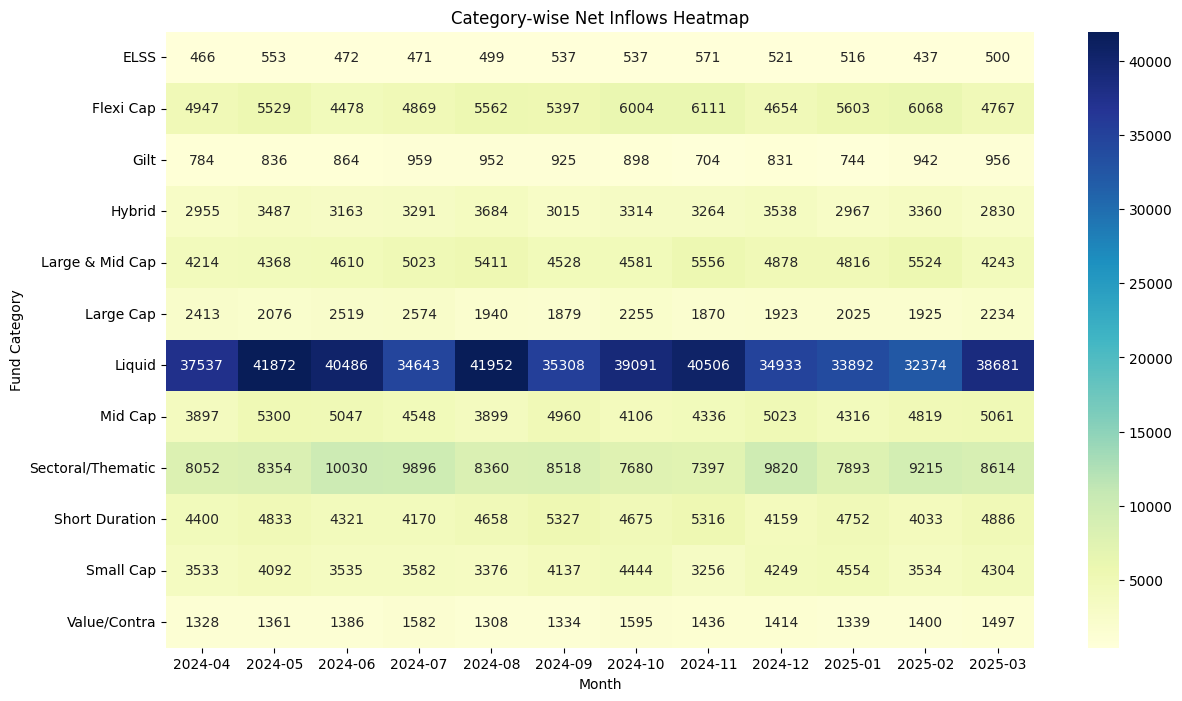

Heatmap saved successfully.


In [136]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
category = pd.read_csv("data/raw/05_category_inflows.csv")

# Create pivot table
pivot_table = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

# Plot heatmap
plt.figure(figsize=(14,8))

sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

# Titles
plt.title("Category-wise Net Inflows Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

# Save chart
plt.savefig("reports/category_inflow_heatmap.png")

# Show chart
plt.show()

print("Heatmap saved successfully.")

### Insight:
Equity-oriented fund categories consistently attracted higher inflows compared to debt and hybrid categories, reflecting stronger investor preference for long-term growth investments.

Investor Demographics

In [137]:
import pandas as pd

df = pd.read_csv("data/raw/08_investor_transactions.csv")

df.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [138]:
df.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

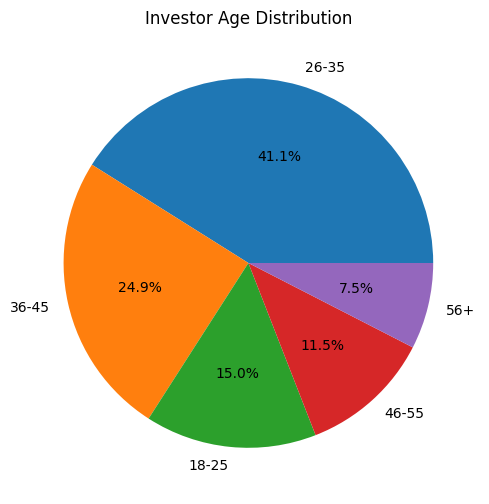

In [139]:
import matplotlib.pyplot as plt

age_counts = df["age_group"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(age_counts, labels=age_counts.index, autopct="%1.1f%%")
plt.title("Investor Age Distribution")
plt.show()

### Insight:
Most investors belong to mid-age groups, indicating stronger participation from working professionals.

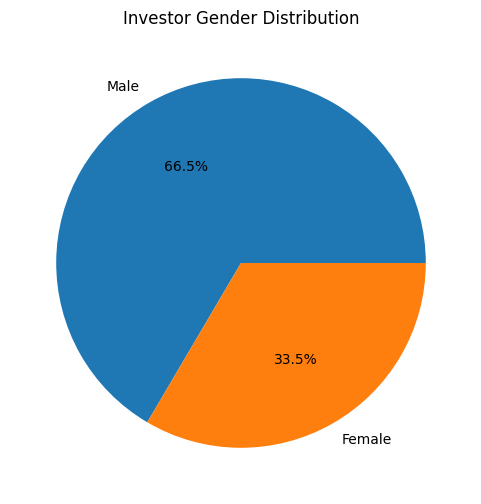

In [140]:
gender_counts = df["gender"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%")
plt.title("Investor Gender Distribution")
plt.show()

### Insight:
Investor participation is fairly balanced across genders with slight skew depending on dataset.

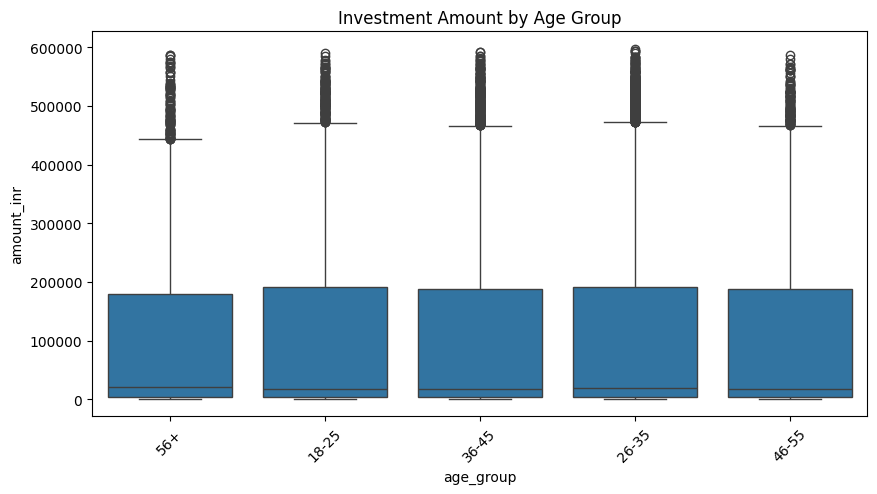

In [141]:
import seaborn as sns

plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")
plt.xticks(rotation=45)
plt.show()

### Insight:
Higher age groups generally show higher investment amounts, indicating higher income stability.

Geographic Distribution

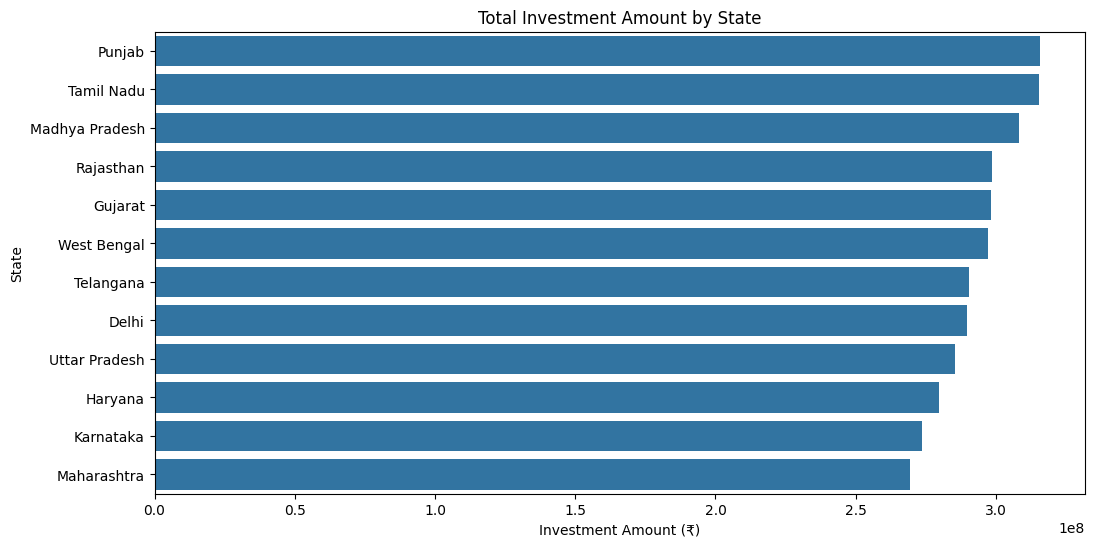

In [142]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("data/raw/08_investor_transactions.csv")

# Group by state
state_data = df.groupby("state")["amount_inr"].sum().sort_values(ascending=False)

# Plot
plt.figure(figsize=(12,6))

sns.barplot(
    x=state_data.values,
    y=state_data.index
)

plt.title("Total Investment Amount by State")
plt.xlabel("Investment Amount (₹)")
plt.ylabel("State")

plt.show()

### Insight:
Major metropolitan states contributed the highest investment amounts, reflecting stronger mutual fund penetration in urban regions.

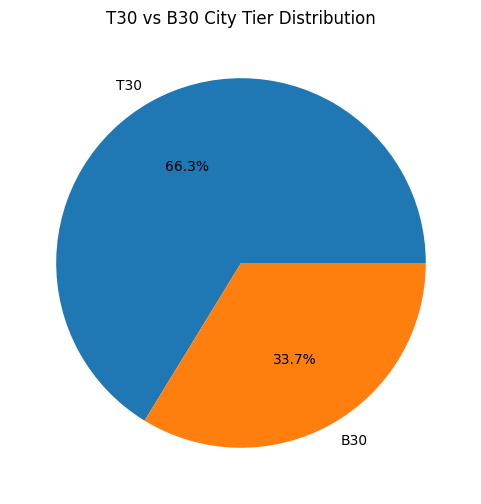

In [143]:
tier_counts = df["city_tier"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 City Tier Distribution")

plt.show()

### Insight:
T30 cities contributed a larger share of investments compared to B30 cities, indicating higher financial market participation in top urban centers.

# Folio Count Growth

In [144]:
import pandas as pd

folio = pd.read_csv("data/raw/06_industry_folio_count.csv")

print(folio.columns)

folio.head()


Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')


,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


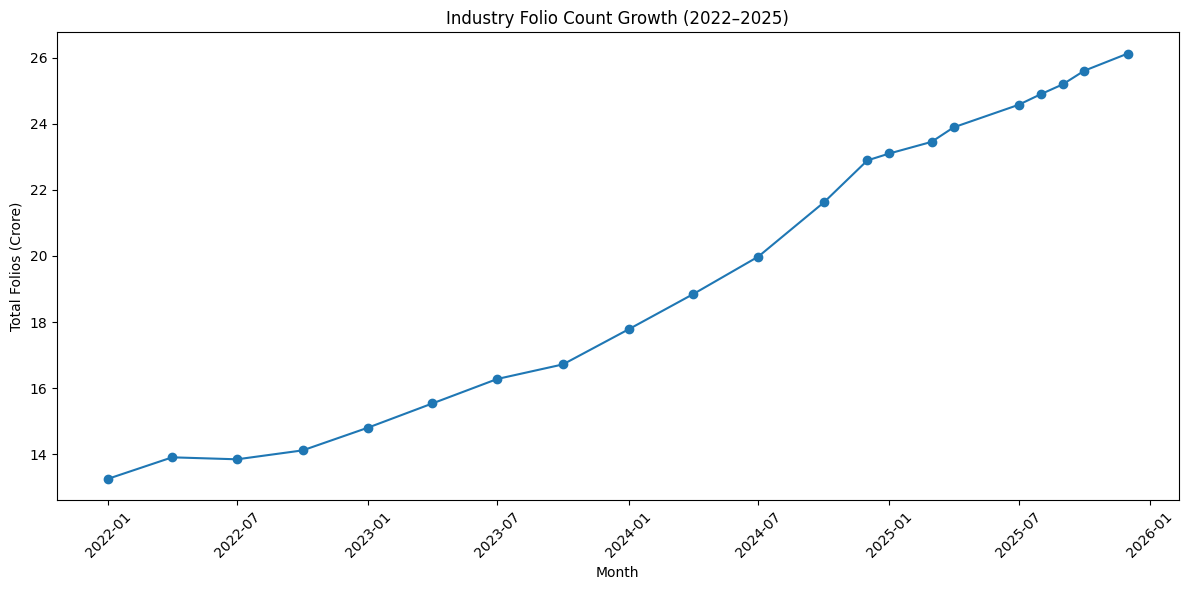

Folio growth chart saved successfully.


In [145]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
folio = pd.read_csv("data/raw/06_industry_folio_count.csv")

# Convert month column
folio["month"] = pd.to_datetime(folio["month"])

# Plot line chart
plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

# Titles
plt.title("Industry Folio Count Growth (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

# Rotate dates
plt.xticks(rotation=45)

# Layout
plt.tight_layout()

# Save chart
plt.savefig("reports/folio_growth_chart.png")

# Show chart
plt.show()

print("Folio growth chart saved successfully.")

### Insight:
Total mutual fund folio counts increased steadily from 2022 to 2025, showing growing investor participation across the industry.

# NAV Return Correlation Matrix

In [146]:
import pandas as pd

nav = pd.read_csv("data/raw/02_nav_history.csv")

print(nav.columns)

nav.head()

Index(['amfi_code', 'date', 'nav'], dtype='str')


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


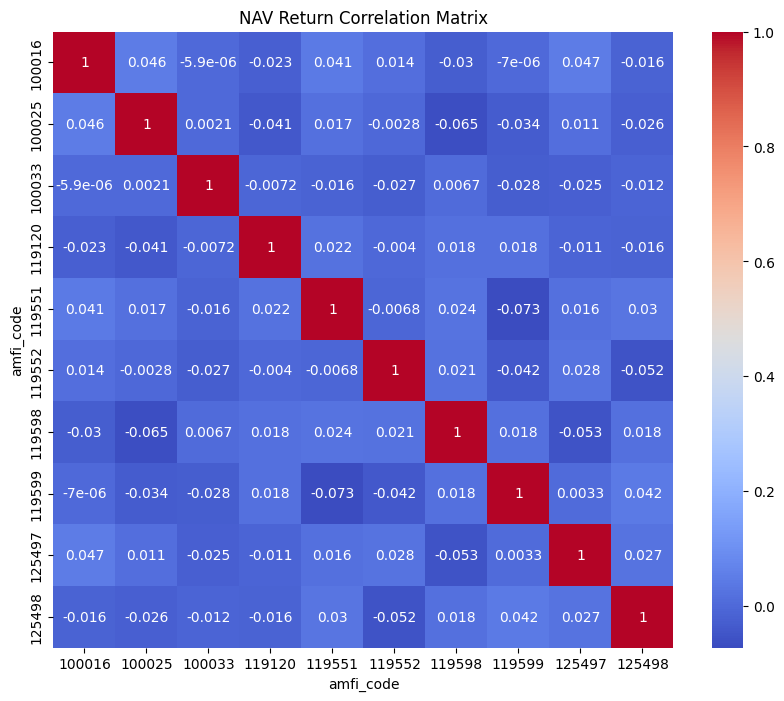

Correlation matrix saved successfully.


In [147]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load NAV dataset
nav = pd.read_csv("data/raw/02_nav_history.csv")

# Convert date column
nav["date"] = pd.to_datetime(nav["date"])

# Select 10 AMFI codes
selected_funds = nav["amfi_code"].unique()[:10]

# Filter data
filtered_nav = nav[
    nav["amfi_code"].isin(selected_funds)
]

# Create pivot table
pivot_nav = filtered_nav.pivot_table(
    index="date",
    columns="amfi_code",
    values="nav"
)

# Calculate daily returns
returns = pivot_nav.pct_change()

# Correlation matrix
corr_matrix = returns.corr()

# Plot heatmap
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

# Title
plt.title("NAV Return Correlation Matrix")

# Save chart
plt.savefig("reports/nav_correlation_matrix.png")

# Show chart
plt.show()

print("Correlation matrix saved successfully.")

### Insight:
Most mutual fund schemes showed positive NAV return correlation, indicating similar movement patterns across equity-oriented funds.

# Sector Allocation Donut Chart

In [148]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
portfolio = pd.read_csv("data/raw/09_portfolio_holdings.csv")

# Check columns
print(portfolio.columns)

portfolio.head()

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


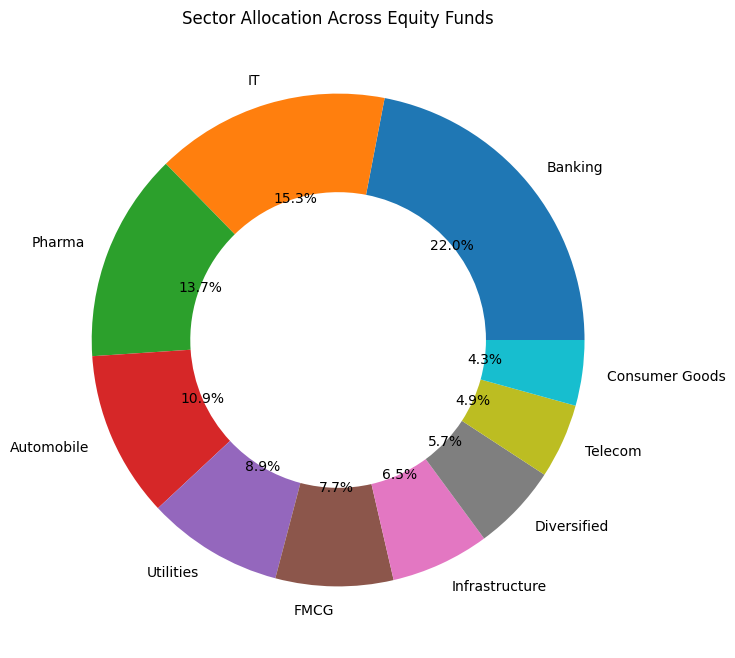

Sector allocation donut chart saved successfully.


In [149]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
portfolio = pd.read_csv("data/raw/09_portfolio_holdings.csv")

# Aggregate sector weights
sector_data = portfolio.groupby("sector")["weight_pct"].sum()

# Select top 10 sectors
sector_data = sector_data.sort_values(ascending=False).head(10)

# Create donut chart
plt.figure(figsize=(8,8))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    wedgeprops=dict(width=0.4)
)

# Title
plt.title("Sector Allocation Across Equity Funds")

# Save chart
plt.savefig("reports/sector_allocation_donut.png")

# Show chart
plt.show()

print("Sector allocation donut chart saved successfully.")

### Insight:
Banking and diversified sectors formed the largest portfolio allocations across mutual fund holdings, indicating strong preference for stable large-cap industries.

# Conclusion

The EDA revealed strong growth in SIP participation, increasing folio counts, dominance of large fund houses like SBI Mutual Fund, and positive correlation among major equity fund NAVs. Investor activity was concentrated in urban regions and working-age demographics.